# 04 — Model Evaluation
Evaluate the best model: actual vs predicted plots, residuals, and feature importances (when available). Save metrics to `models/model_metrics.json`.

In [1]:
# Setup
import sys, os, json
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd()))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from src.train_models import load_processed, build_supervised, split_dataset, evaluate
from src.utils import MODELS_DIR, SAVED_MODELS_DIR
from src.visualize import save_current_fig

In [9]:
# Recreate the split and load the best model
df = load_processed()
X, y = build_supervised(df)
dataset = split_dataset(X, y, test_size=0.2)
bundle = joblib.load(SAVED_MODELS_DIR / 'best_model.joblib')
best_model = bundle['model']

In [10]:
# Predictions and metrics
y_pred = best_model.predict(dataset.X_test)
metrics = evaluate(dataset.y_test, y_pred)
metrics

ValueError: X has 8 features, but Lasso is expecting 13 features as input.

PosixPath('/workspaces/climate-ml-lab/visuals/actual_vs_predicted.png')

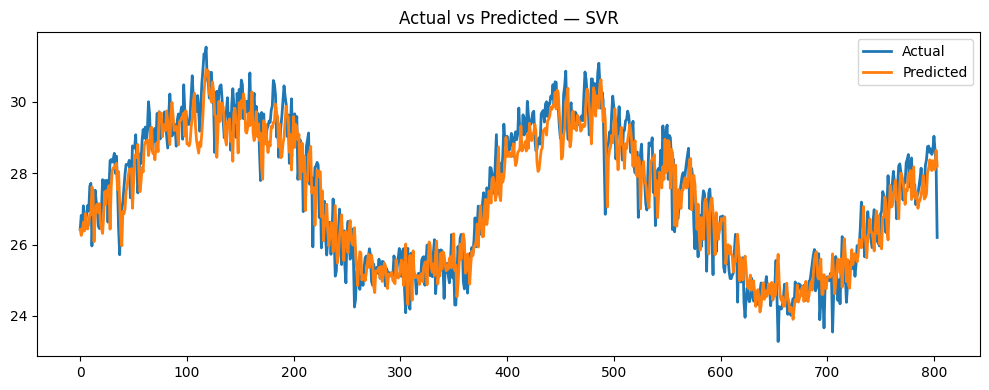

In [4]:
# Actual vs Predicted plot
plt.figure(figsize=(10,4))
plt.plot(dataset.y_test, label='Actual', lw=2)
plt.plot(y_pred, label='Predicted', lw=2)
plt.title(f'Actual vs Predicted — {best_name}')
plt.legend()
path = save_current_fig('actual_vs_predicted.png')
path

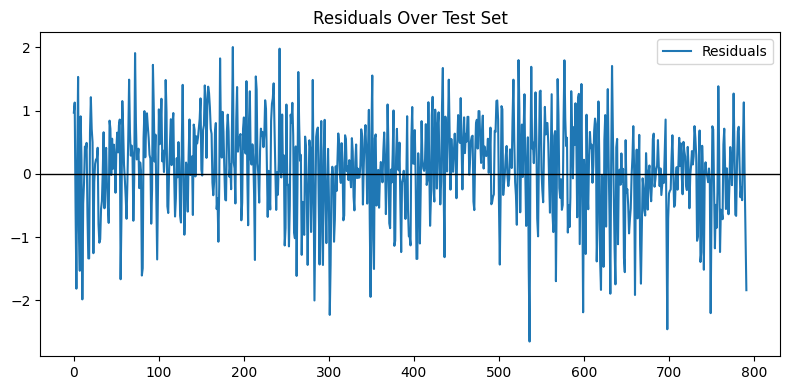

In [5]:
# Residual plot
resid = dataset.y_test - y_pred
plt.figure(figsize=(8,4))
plt.plot(resid, label='Residuals')
plt.axhline(0, color='black', lw=1)
plt.title('Residuals Over Test Set')
plt.legend()
save_current_fig('residuals_plot.png')
plt.show()

In [6]:
# Feature importances for tree-based models (if available)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    idx = np.argsort(importances)[::-1]
    names = np.array(dataset.feature_names)[idx]
    vals = importances[idx]
    plt.figure(figsize=(10,5))
    plt.bar(names[:20], vals[:20])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Feature Importances — {best_name}')
    save_current_fig('feature_importances.png')
    plt.show()
else:
    print('No feature_importances_ attribute for model:', best_name)

No feature_importances_ attribute for model: SVR


In [7]:
# Save metrics to models/model_metrics.json
MODELS_DIR.mkdir(parents=True, exist_ok=True)
metrics_path = MODELS_DIR / 'model_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
metrics_path, metrics

(PosixPath('/workspaces/climate-ml-lab/models/model_metrics.json'),
 {'MAE': 0.5990239137497079,
  'RMSE': 0.7578767492851701,
  'R2': 0.8553970509863684})